<a href="https://colab.research.google.com/github/rachakondasaivarshini/AIML-EXPS/blob/main/AIML_EXP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial Shape: (891, 15)

Columns:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Final Columns:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'who',
       'adult_male', 'alone', 'class_Second', 'class_Third', 'embarked_Q',
       'embarked_S'],
      dtype='object')
Final Shape: (891, 14)


/tmp/ipykernel_1875/3113521032.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_1875/3113521032.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

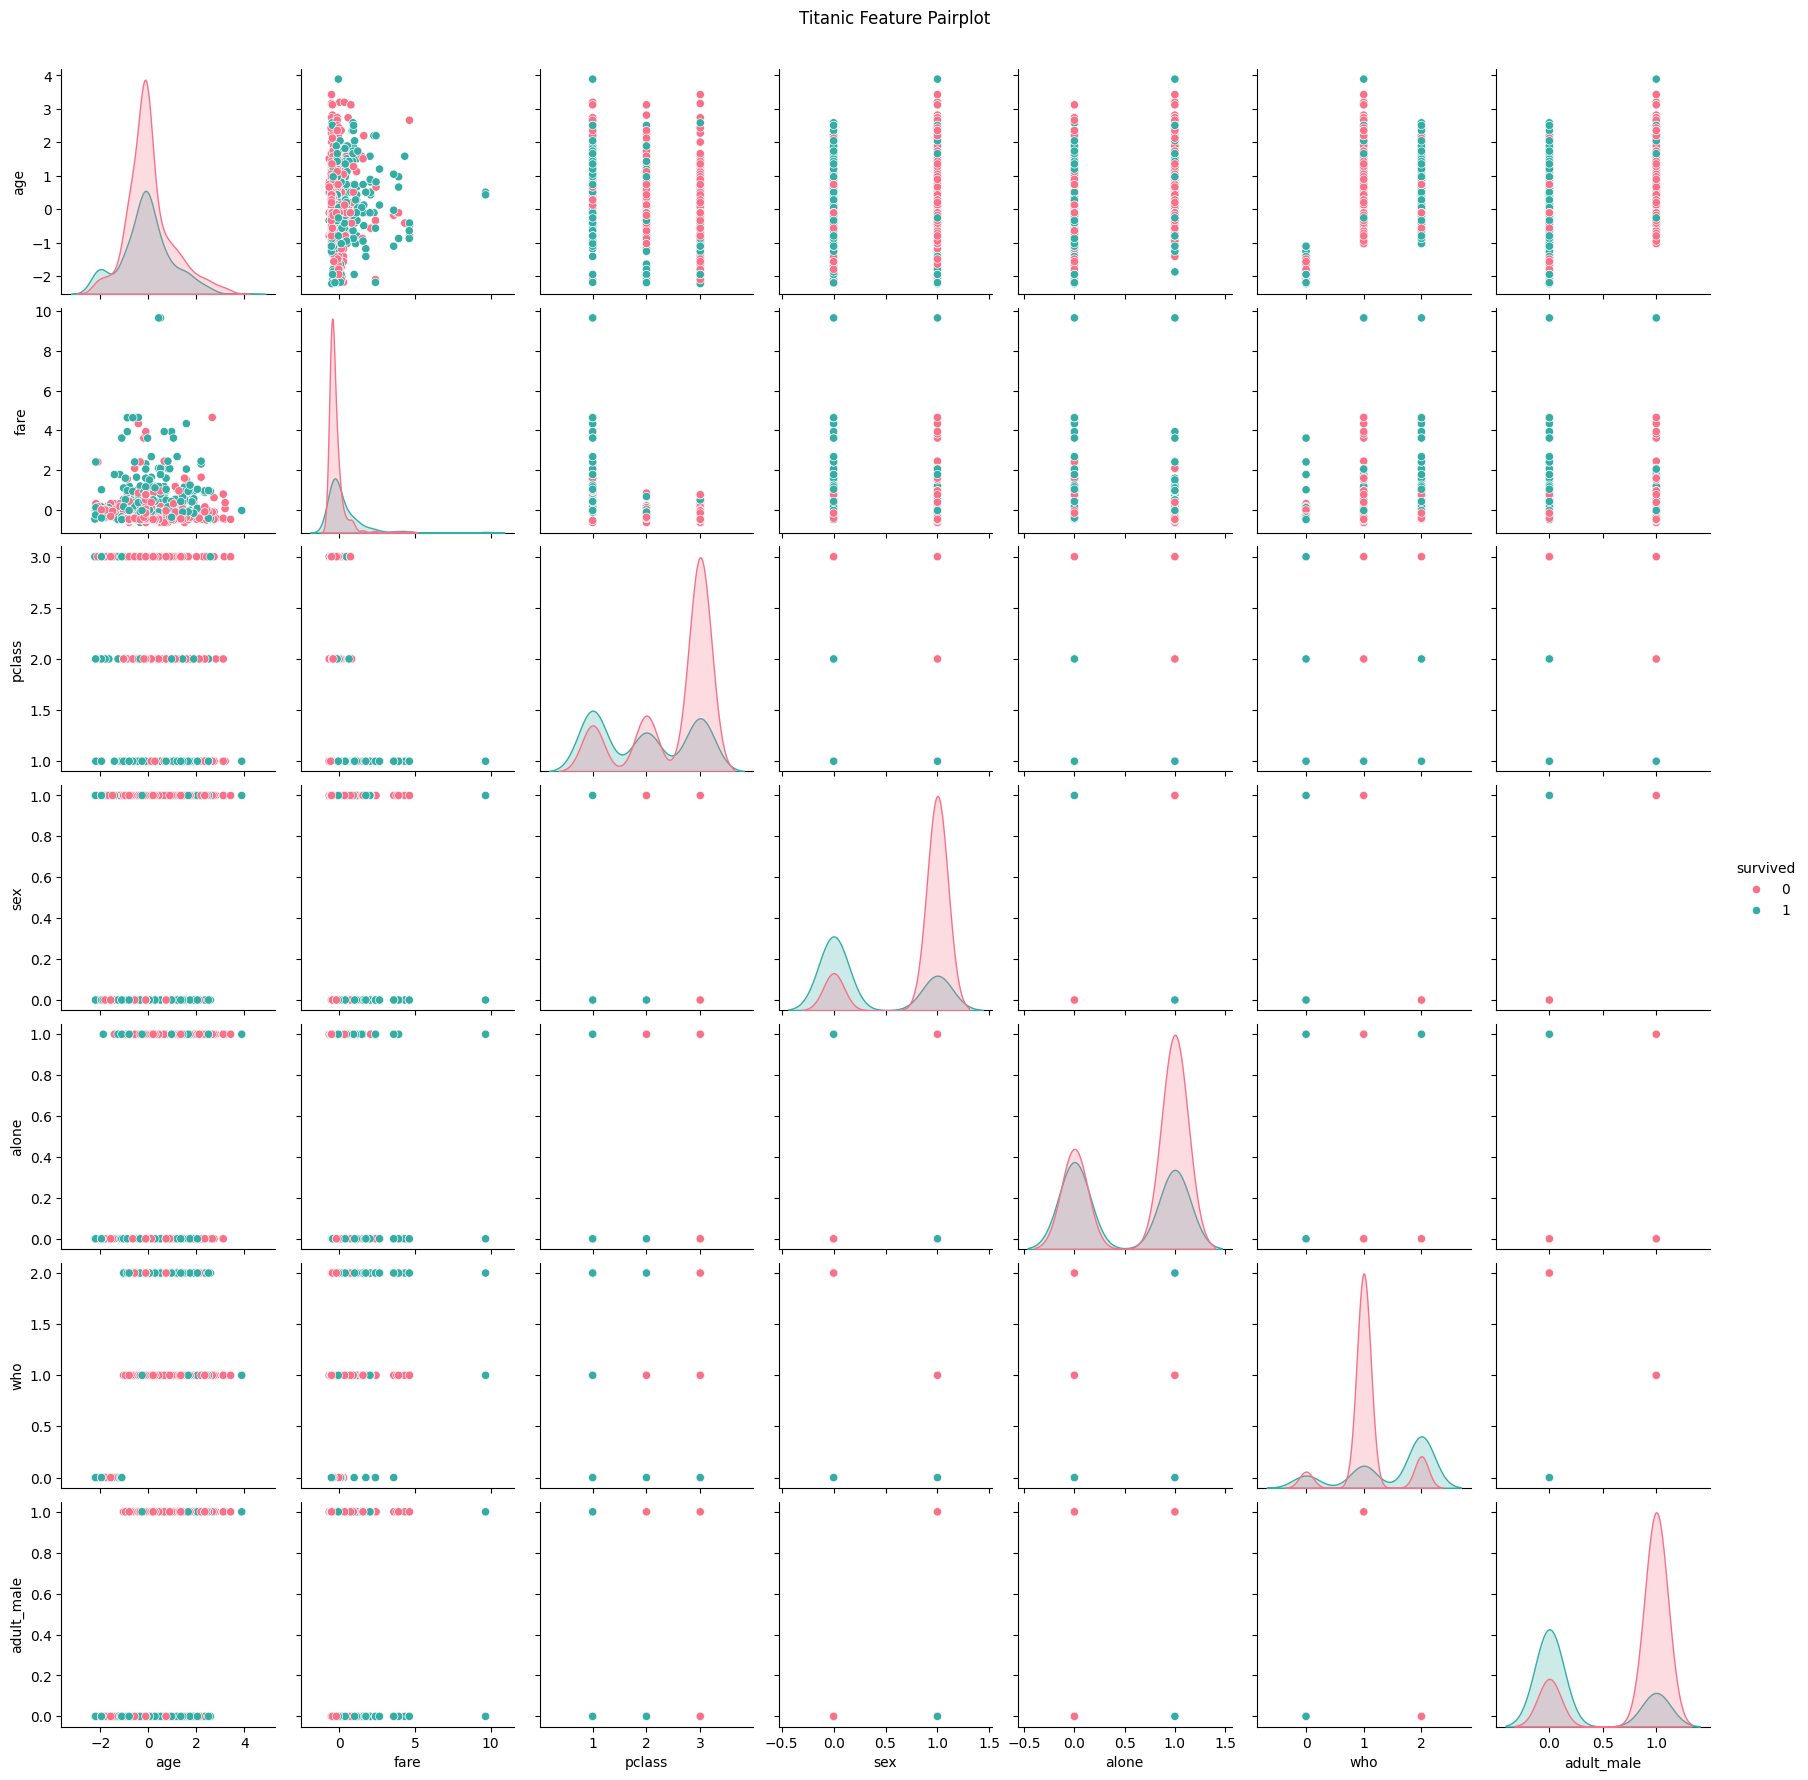

Processed data saved to 'titanic_processed_combined.csv'

First 5 rows of processed dataset:
   survived  pclass  sex       age  sibsp  parch      fare  who  adult_male  \
0         0       3    1 -0.565736      1      0 -0.502445    1           1   
1         1       1    0  0.663861      1      0  0.786845    2           0   
2         1       3    0 -0.258337      0      0 -0.488854    2           0   
3         1       1    0  0.433312      1      0  0.420730    2           0   
4         0       3    1  0.433312      0      0 -0.486337    1           1   

   alone  class_Second  class_Third  embarked_Q  embarked_S  
0      0         False         True       False        True  
1      0         False        False       False       False  
2      1         False         True       False        True  
3      0         False        False       False        True  
4      1         False         True       False        True  


In [1]:
# Step 1 – Import Required Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 2 – Load the Dataset
df = sns.load_dataset('titanic')

print("Initial Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nMissing Values:")
print(df.isnull().sum())

# Step 3 – Drop Less Useful Columns
df.drop(columns=['deck', 'embark_town', 'alive'], inplace=True)

# Step 4 – Handle Missing Values
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Step 5a – Label Encoding
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['who'] = le.fit_transform(df['who'])
df['alone'] = le.fit_transform(df['alone'])
df['adult_male'] = le.fit_transform(df['adult_male'])

# Step 5b – One-Hot Encoding
df = pd.get_dummies(df, columns=['class', 'embarked'], drop_first=True)

# Step 6 – Feature Scaling
scaler = StandardScaler()
df[['age', 'fare']] = scaler.fit_transform(df[['age', 'fare']])

# Step 7 – Display Final Structure
print("\nFinal Columns:")
print(df.columns)
print("Final Shape:", df.shape)

# Step 8 – Visualize with Pairplot
selected_features = [
    'survived', 'age', 'fare',
    'pclass', 'sex', 'alone',
    'who', 'adult_male'
]

sns.pairplot(df[selected_features],
             hue='survived',
             palette='husl')
plt.suptitle("Titanic Feature Pairplot", y=1.02)
plt.show()

# Step 9 – Save to CSV
df.to_csv('titanic_processed_combined.csv', index=False)
print("Processed data saved to 'titanic_processed_combined.csv'")

# Print first 5 rows
print("\nFirst 5 rows of processed dataset:")
print(df.head())